# Otimização e Validação Cruzada

Neste notebook, vamos aprofundar a análise dos modelos utilizados anteriormente na previsão da série __AirPassengers__:
- SARIMA  
- LSTM  
- Random Forest  
- XGBoost  

Ao longo deste projecto, explorámos a preparação de dados, a implementação de modelos e a análise básica de desempenho. Agora é altura de elevar essa análise com duas abordagens fundamentais:
- **Fine-Tuning** - Aplicar técnicas de otimização de hiperparâmetros para melhorar o desempenho dos modelos;
- **Cross-Validation** - Introduzir a validação cruzada apropriada para séries temporais, usando técnicas como o `TimeSeriesSplit`.

Após essa análise vamos comparar os modelos (MAE, RMSE, R²) e visualizar as previsões e os erros de forma clara, de modo, a realizar uma análise crítica do comportamento de cada modelo.

**Nota:**
 - O modelo **SARIMA** foi previamente estudado e otimizado no notebook dedicado aos modelos clássicos, utilizando o método `auto_arima`. Esta ferramenta foi desenhada especificamente para ajustar automaticamente os melhores parâmetros estatísticos para modelos ARIMA/SARIMA, com base em métricas como AIC e BIC;
 - Neste notebook, o foco será exclusivamente nos modelos de Machine Learning (Random Forest, XGBoost e LSTM), os quais requerem estratégias distintas de otimização como o `GridSearchCV` e validação cruzada adaptada a séries temporais;
 - Assim, não será realizada nova otimização ao modelo SARIMA, sendo apenas considerado na fase de comparação final de desempenho.


## Fine-Tuning e Cross-Validation

A escolha dos **hiperparâmetros** certos pode fazer uma diferença significativa na performance de um modelo. Técnicas como `GridSearchCV`, `RandomizedSearchCV` ou bibliotecas como `Optuna` permitem automatizar esse processo.

Por outro lado, a **validação cruzada tradicional** (K-Fold) não respeita a ordem temporal dos dados, podendo introduzir *data leakage*. No estudo de séries temporais é necessário usar uma abordagem que valide os modelos de uma forma sequencial como `TimeSeriesSplit`, simulando melhor a realidade.

Com estas ferramentas, vamos obter uma avaliação mais justa e precisa dos modelos.

### GridSearchCV: Otimização de Hiperparâmetros com Validação Cruzada

Neste projeto vamos utilizar o método **GridSearchCV** da biblioteca `scikit-learn`.

O `GridSearchCV` permite realizar uma **busca exaustiva** sobre uma grelha (grid) de combinações de hiperparâmetros definidos pelo utilizador. Para cada combinação possível, o modelo é avaliado utilizando **validação cruzada**, proporcionando uma estimativa robusta do desempenho do modelo em dados não vistos.

Este processo garante que:
- Os melhores parâmetros são escolhidos com base numa métrica de avaliação (ex: MAE, RMSE);
- O modelo não está a sobreajustar (overfitting) aos dados de treino;
- É mantida a integridade temporal dos dados, utilizando validação cruzada adequada ao contexto de séries temporais.

Os hiperparâmetros definidos para cada modelo foram selecionados com base na sua relevância para o desempenho e complexidade do algoritmo.  
O objetivo é encontrar um equilíbrio entre capacidade preditiva e custo computacional, assegurando uma otimização eficiente durante o processo de validação cruzada.

In [1]:
# Importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_importance
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout # type: ignore
from tensorflow.keras.optimizers import Adam, RMSprop, Nadam # type: ignore
from scikeras.wrappers import KerasRegressor

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Preparação do dataset

# Ler o dataset
df = pd.read_csv('./Datasets/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# Mudar o nome da coluna '#Passengers'
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Criação de Features Temporais
df['lag1'] = df['Passengers'].shift(1)
df['lag2'] = df['Passengers'].shift(2)
df['rolling_mean_3'] = df['Passengers'].rolling(window=3).mean()
df['month'] = df.index.month # type: ignore

# Retirar valores NaN's
df.dropna(inplace=True)

# Divisão do dataset em features e target (X, y)
X = df[['lag1', 'lag2', 'rolling_mean_3', 'month']]
y = df[['Passengers']]

# Divisão em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# Neste notebook vamos utilizar o dataset normalizado para todos modelos
# X e y têm escalas diferentes e cada um precisa de ser normalizado de forma independente.
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Normalizar apenas com base no treino para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)

# Validação cruzada
tscv = TimeSeriesSplit(n_splits=5)


In [3]:
# Construção do modelo Random Forest

# Parâmetros a explorar no GridSearchCV
rf_param_grid = {'n_estimators': [100, 200],
                 'max_depth': [3, 5, 10],
                 'min_samples_split': [2, 5]}

# Modelo Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Otimizador
rf_grid_search = GridSearchCV(estimator=rf_model,
                              param_grid=rf_param_grid,
                              cv=tscv,
                              scoring='neg_mean_squared_error',
                              n_jobs=-1,
                              verbose=1)

# Treinar o modelo
rf_grid_search.fit(X_train_scaled, y_train_scaled)

# Previsões
best_rf_model = rf_grid_search.best_estimator_
y_pred_scaled = best_rf_model.predict(X_test_scaled)

# Inversão da normalização
y_pred_rf = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Métricas de Avaliação
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_score_rf = r2_score(y_test, y_pred_rf)

print("Melhores parâmetros:", rf_grid_search.best_params_)
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R2_score: {r2_score_rf:.2f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
RMSE: 63.47
MAE: 41.19
R2_score: 0.34


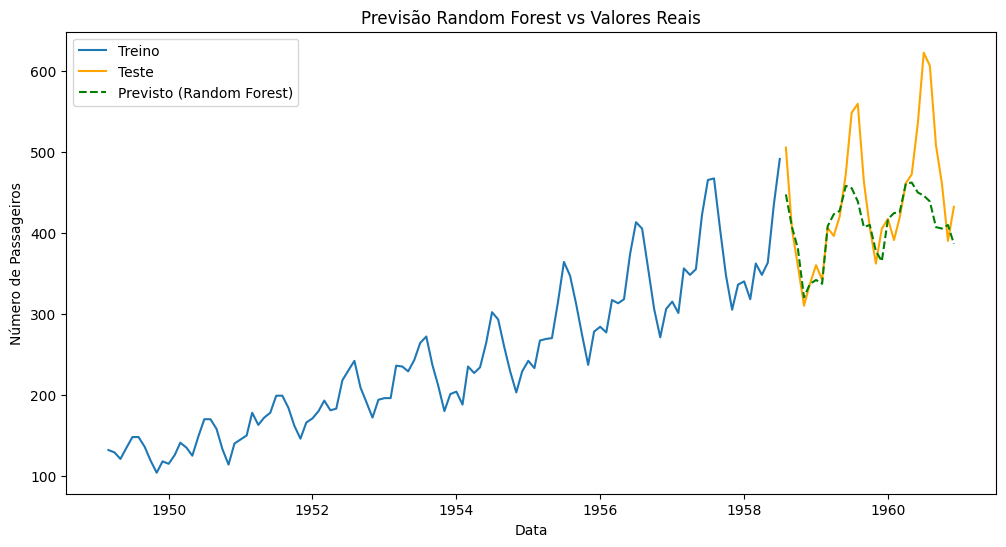

In [4]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_rf, label='Previsto (Random Forest)', color='green', linestyle='--')
plt.title('Previsão Random Forest vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

In [5]:
# Construção do modelo XGBRegressor

# Parâmetros a explorar no GridSearchCV
xgb_param_grid = {'n_estimators': [100, 200, 300],
                  'max_depth': [3, 5, 10],
                  'min_child_weight': [1, 3, 5],
                  'learning_rate': [0.01, 0.05, 0.1],
                  'subsample': [0.8, 1.0],
                  'colsample_bytree': [0.8, 1.0]}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_grid_search = GridSearchCV(estimator=xgb_model,
                               param_grid=xgb_param_grid,
                               cv=tscv,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1, verbose=1)

# Treinar o modelo
xgb_grid_search.fit(X_train_scaled, y_train_scaled)

# Previsões
xgb_best_model = xgb_grid_search.best_estimator_
y_pred_scaled = xgb_best_model.predict(X_test_scaled)

# Inversão da normalização
y_pred_xgb = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Métricas de Avaliação
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_score_xgb = r2_score(y_test, y_pred_xgb)

print("Melhores parâmetros:", xgb_grid_search.best_params_)
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2_score: {r2_score_xgb:.2f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
RMSE: 70.64
MAE: 45.34
R2_score: 0.18


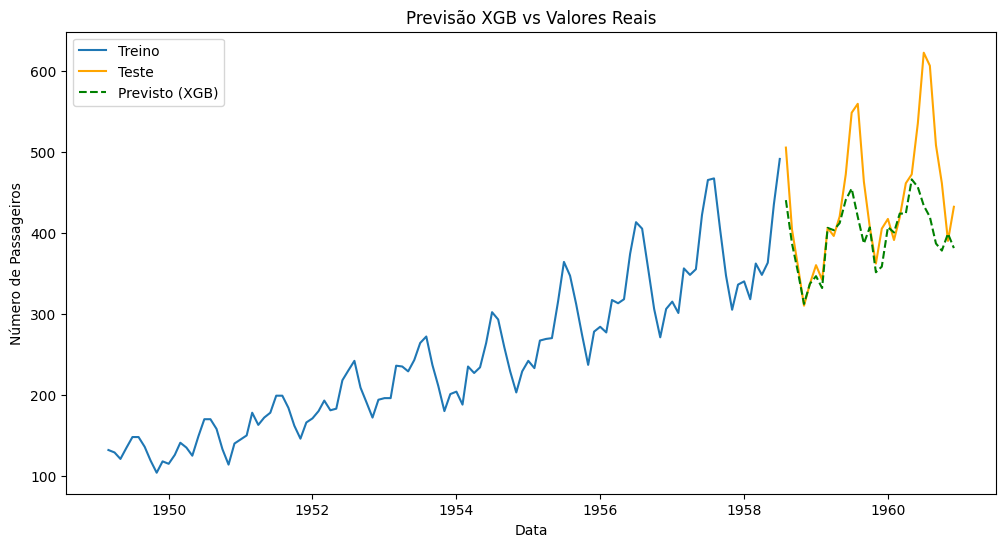

In [6]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_xgb, label='Previsto (XGB)', color='green', linestyle='--')
plt.title('Previsão XGB vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### Reavaliação e Melhoria do Modelo XGBoost

Com base nas métricas de desempenho e na análise da importância das features, fica evidente que o modelo XGBoost pode beneficiar de melhorias adicionais.

#### Ajustes na Engenharia de Features
- Criar novas variáveis (ex: médias móveis com diferentes janelas, diferenças sazonais, interação entre variáveis, etc.);
- Verificar a correlação entre features;
- Testar a redução ou substituição de variáveis com baixa importância.

#### Refinamento dos Hiperparâmetros
- Expandir o espaço de busca no `GridSearchCV` para explorar mais combinações;
- Incluir novos hiperparâmetros relevantes, como `learning_rate`, `subsample`, `colsample_bytree`, `gamma`, etc.;
- Manter a validação cruzada com `TimeSeriesSplit` para garantir robustez.


In [7]:
# Vamos adicionar as seguintes variáveis ao dataset:
# lag3, lag4, lag5 – Mais defasagens (lags) para captar padrões de curto prazo.
# rolling_std_3 – Desvio padrão móvel (3 meses), para representar a variabilidade recente.
# rolling_mean_6 – Média móvel de 6 meses, para captar tendência de médio prazo.
# quarter – Trimestre do ano, que pode ajudar a identificar padrões sazonais.

# Novas Features Temporais
df['lag3'] = df['Passengers'].shift(3)
df['lag4'] = df['Passengers'].shift(4)
df['lag5'] = df['Passengers'].shift(5)

df['rolling_mean_6'] = df['Passengers'].rolling(window=6).mean()
df['rolling_std_3'] = df['Passengers'].rolling(window=3).std()

df['quarter'] = df.index.quarter  # type: ignore # Trimestre do ano

# Remover valores nulos gerados pelas novas features
df.dropna(inplace=True)

# Ordenar Dataset
df = df[['lag1', 'lag2', 'lag3', 'lag4', 'lag5',
         'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3',
         'month', 'quarter', 'Passengers']]

# Visualizar dataset
df.head()

,lag1,lag2,lag3,lag4,lag5,rolling_mean_3,rolling_mean_6,rolling_std_3,month,quarter,Passengers
Month,,,,,,,,,,,
1949-08-01,148.0,135.0,121.0,129.0,132.0,143.666667,135.500000,7.505553,8,3,148
1949-09-01,148.0,148.0,135.0,121.0,129.0,144.000000,136.166667,6.928203,9,3,136
1949-10-01,136.0,148.0,148.0,135.0,121.0,134.333333,134.500000,14.571662,10,4,119
1949-11-01,119.0,136.0,148.0,148.0,135.0,119.666667,131.666667,16.010413,11,4,104
1949-12-01,104.0,119.0,136.0,148.0,148.0,113.666667,128.833333,8.386497,12,4,118


In [8]:
# Divisão do dataset em features e target (X, y)
X = df[['lag1', 'lag2', 'lag3', 'lag4', 'lag5',
        'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3',
        'month', 'quarter']]

y = df[['Passengers']]

# Divisão em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# X e y têm escalas diferentes e cada um precisa de ser normalizado de forma independente.
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Normalizar apenas com base no treino para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)

# Validação cruzada
tscv = TimeSeriesSplit(n_splits=5)

In [9]:
# Construção do modelo XGBRegressor

# Parâmetros a explorar no GridSearchCV
# xgb_param_grid = {'n_estimators': [100, 200, 300, 400],
#                   'max_depth': [3, 4, 5, 6, 7],
#                   'learning_rate': [0.01, 0.05, 0.1, 0.2],
#                   'subsample': [0.6, 0.7, 0.8, 0.9],
#                   'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
#                   'min_child_weight': [1, 3, 5],
#                   'gamma': [0, 0.1, 0.2],
#                   'reg_alpha': [0, 0.1, 0.01],
#                   'reg_lambda': [1, 10, 100]}

# xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# xgb_grid_search = GridSearchCV(estimator=xgb_model,
#                                param_grid=xgb_param_grid,
#                                cv=tscv,
#                                scoring='neg_mean_squared_error',
#                                n_jobs=-1, verbose=1)

# # Treinar o modelo
# xgb_grid_search.fit(X_train_scaled, y_train_scaled)

# # Previsões
# xgb_best_model = xgb_grid_search.best_estimator_
# y_pred_scaled = xgb_best_model.predict(X_test_scaled)

# # Inversão da normalização
# y_pred_xgb = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# # Métricas de Avaliação
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# r_2_score_xgb = r2_score(y_test, y_pred_xgb)

# print("Melhores parâmetros:", xgb_grid_search.best_params_)
# print(f"RMSE (teste): {rmse_xgb:.2f}")
# print(f"MAE (teste): {mae_xgb:.2f}")
# print(f"R2_score (teste): {r_2_score_xgb:.2f}")


# Resultados:
# Fitting 5 folds for each of 103680 candidates, totalling 518400 fits
# Melhores parâmetros: {'colsample_bytree': 0.9,
#                       'gamma': 0, 'learning_rate': 0.2,
#                       'max_depth': 3, 'min_child_weight': 3,
#                       'n_estimators': 400, 'reg_alpha': 0.01, 
#                       'reg_lambda': 1, 'subsample': 0.9}

# RMSE (teste): 63.23
# MAE (teste): 47.23
# R2_score (teste): 0.35

# A execução desta célula demora cerca de 2 horas a concluir, por esse motivo ficou comentada.

In [10]:
# Construção do modelo utilizando os resultados anteriores

# Melhores parâmetros:
xgb2_params = {'colsample_bytree': 0.9,
               'gamma': 0,
               'learning_rate': 0.2,
               'max_depth': 3,
               'min_child_weight': 3,
               'n_estimators': 400,
               'reg_alpha': 0.01,
               'reg_lambda': 1,
               'subsample': 0.9}

# Modelo
xgb2_model = XGBRegressor(**xgb2_params,
                          cv=tscv,
                          scoring='neg_mean_squared_error',
                          random_state=42,
                          n_jobs=-1)

# Treinar o modelo
xgb2_model.fit(X_train_scaled, y_train_scaled)

# Previsões
y_pred_scaled = xgb2_model.predict(X_test_scaled)

# Inversão da normalização
y_pred_xgb2 = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Métricas de Avaliação
rmse_xgb2 = np.sqrt(mean_squared_error(y_test, y_pred_xgb2))
mae_xgb2 = mean_absolute_error(y_test, y_pred_xgb2)
r2_score_xgb2 = r2_score(y_test, y_pred_xgb2)

print('Resultados:')
print(f"RMSE (teste): {rmse_xgb2:.2f}")
print(f"MAE (teste): {mae_xgb2:.2f}")
print(f"R2_score (teste): {r2_score_xgb2:.2f}")


Resultados:
RMSE (teste): 63.23
MAE (teste): 47.23
R2_score (teste): 0.35


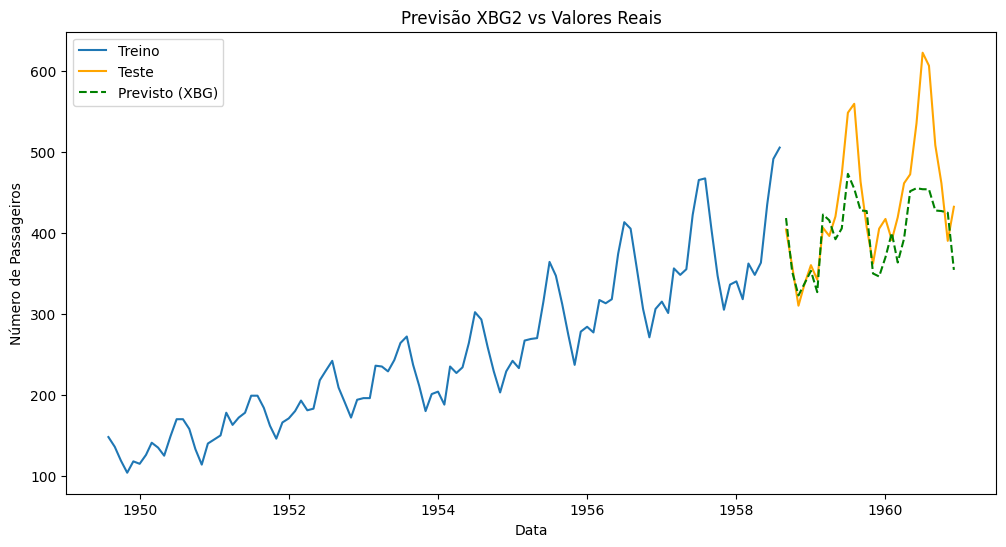

In [11]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_xgb2, label='Previsto (XBG)', color='green', linestyle='--')
plt.title('Previsão XBG2 vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### Análise da situação atual

Expandi significativamente o espaço de busca no param_grid antes de analisar a eficácia das novas features. Isso resultou num tempo de execução elevado (~2 horas) numa otimização baseada em features que não foram devidamente analisadas. As mesmas podem ser consideradas redundantes ou pouco informativas e serem retiradas do dataset diminuído assim a complexidade e o tempo de execução.

Com o problema bem identificado vamos recomeçar o estudo das novas features e relembrar que "saltar passos" pode atrasar em muito o desenvolvimento do modelo.

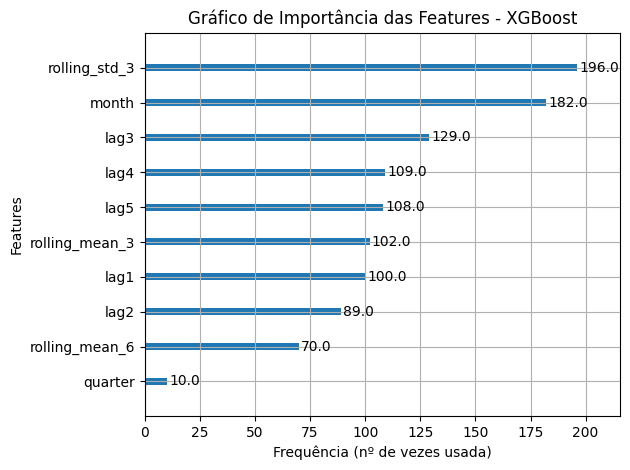

In [12]:
# A função plot_importance() do XGBoost mostra a contribuição de cada feature na construção das árvores.

# Lista com os nomes reais das features
feature_names = X_train.columns  # Assume que X_train é um DataFrame com nomes das colunas

# Atualiza o booster com os nomes das features
xgb2_model.get_booster().feature_names = list(feature_names)

# Gráfico de importância das features
plot_importance(xgb2_model, importance_type='weight', xlabel='Frequência (nº de vezes usada)')
plt.title('Gráfico de Importância das Features - XGBoost')
plt.tight_layout()
plt.show()

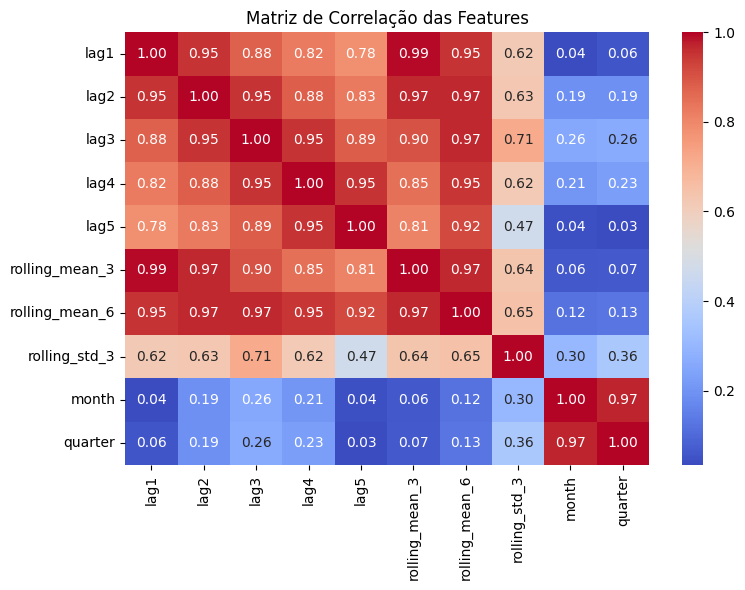

In [13]:
# A matriz de correlação mostra se há features altamente correlacionadas (ex: lag1 e lag2).
# Isso pode indicar redundância.

# Correlação entre todas as features
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Features')
plt.tight_layout()
plt.show()

#### Gráfico de Importância (plot_importance)
As features mais utilizadas pelo modelo foram:
- rolling_std_3 (usada 196 vezes)
- month (182 vezes)

A feature quarter foi usada apenas 10 vezes, o que sugere baixa relevância.


#### Matriz de Correlação
Há muita multicolinearidade entre:
- lag1 e lag2 (0.95)
- lag1 e rolling_mean_3 (0.99)
- lag2 e rolling_mean_3 (0.97)
- rolling_mean_3 e rolling_mean_6 (0.97)


#### Remoção de Features Redundantes
Com base na análise conjunta da importância das features no modelo XGBoost e da matriz de correlação, identificámos variáveis que demonstram ser pouco informativas ou altamente redundantes. A estratégia adotada visa reduzir a multicolinearidade e simplificar o modelo, mantendo apenas as variáveis com maior valor preditivo e menos sobreposição de informação.

As seguintes features foram removidas:
- **quarter:** Apresenta baixa importância no modelo (apenas 10 utilizações) e correlação quase nula com as restantes variáveis, indicando baixo valor preditivo;
- **lag2:** Fortemente correlacionada com lag1 e rolling_mean_3 (coef. > 0.95), oferecendo informação redundante;
- **rolling_mean_3:** Embora utilizada com frequência, tem correlação extremamente alta com lag1 (coef. 0.99), tornando-se redundante;
- **rolling_mean_6:** Apresenta menor importância e correlação elevada com rolling_mean_3, já descartada nesta abordagem.

Esta seleção visa melhorar a capacidade de generalização do modelo, reduzir o risco de overfitting e acelerar o processo de treino, ao mesmo tempo que se preserva a informação relevante para a previsão (forecasting).



In [14]:
# Lista de features a remover com base na análise anterior
features_a_remover = ['quarter', 'lag2', 'rolling_mean_3', 'rolling_mean_6']

# Filtrar o dataset de treino e teste
X_train_filtrado = X_train.drop(columns=features_a_remover)
X_test_filtrado = X_test.drop(columns=features_a_remover)

# Confirmar as novas features
print("Features utilizadas após filtragem:", X_train_filtrado.columns.tolist())

Features utilizadas após filtragem: ['lag1', 'lag3', 'lag4', 'lag5', 'rolling_std_3', 'month']


In [15]:
# Normalizar apenas com base no treino para evitar data leakage
X_train_scaled_filtrado = scaler_X.fit_transform(X_train_filtrado)
X_test_scaled_filtrado = scaler_X.transform(X_test_filtrado)

# Treinar o modelo
xgb2_model.fit(X_train_scaled_filtrado, y_train_scaled)

# Previsões
y_pred_scaled_filtrado = xgb2_model.predict(X_test_scaled_filtrado)

# Inversão da normalização
y_pred_xgb_filtrado = scaler_y.inverse_transform(y_pred_scaled_filtrado.reshape(-1, 1))

# Métricas de Avaliação
rmse_xgb_filtrado = np.sqrt(mean_squared_error(y_test, y_pred_xgb_filtrado))
mae_xgb_filtrado = mean_absolute_error(y_test, y_pred_xgb_filtrado)
r2_score_xgb_filtrado = r2_score(y_test, y_pred_xgb_filtrado)

print('Resultados:')
print(f"RMSE (teste): {rmse_xgb_filtrado:.2f}")
print(f"MAE (teste): {mae_xgb_filtrado:.2f}")
print(f"R2_score (teste): {r2_score_xgb_filtrado:.2f}")

Resultados:
RMSE (teste): 60.33
MAE (teste): 45.29
R2_score (teste): 0.41


#### Comparação dos Resultados

| Métrica     | Antes | Depois | Melhoria?       |
|-------------|--------|--------|-----------------|
| **RMSE**    | 63.23  | 60.33  | ✅ Sim (↓)       |
| **MAE**     | 47.23  | 45.29  | ✅ Sim (↓)       |
| **R² Score**| 0.35   | 0.41   | ✅ Sim (↑)       |

**Redução do Erro (RMSE e MAE):** A queda nos valores de erro mostra que o modelo ficou mais preciso, cometendo menos desvios em média, tanto grandes (RMSE) como absolutos (MAE).  
**Aumento do R²:** Um salto de 0.35 para 0.41 significa que o modelo passou a explicar mais variância dos dados, o que é um sinal forte de melhoria na generalização.

Esta melhoria foi conseguida sem aumentar a complexidade (sem tuning novo, sem novas features), apenas com uma seleção mais criteriosa.


### Reavaliação e Otimização do Modelo LSTM

Na versão anterior do modelo, os resultados obtidos foram os seguintes:

- **MSE**: 4343.79  
- **RMSE**: 65.91  
- **MAE**: 53.12  
- **R² Score**: 0.2884

Esta etapa foca-se na melhoria do modelo LSTM através de duas estratégias principais:

#### 1. Engenharia de Features
A engenharia de features foi previamente realizada no estudo do modelo XGBoost, onde foram criadas variáveis como lags, médias móveis, desvio padrão e variáveis sazonais. Estas mesmas features serão reutilizadas neste modelo, com as devidas adaptações ao formato de entrada exigido pelo LSTM.

#### 2. Otimização de Arquitetura e Hiperparâmetros
Será explorado um conjunto de melhorias ao nível do modelo, incluindo:
- Ajuste do número de unidades LSTM;
- Uso de camadas adicionais e Dropout para evitar overfitting;
- Teste de diferentes tamanhos de batch, épocas e funções de ativação;
- Avaliação de diferentes otimizadores (como `adam`, `rmsprop`, etc.).

O objetivo final é construir um modelo LSTM mais robusto, capaz de competir em desempenho com os modelos baseados em árvores e métodos estatísticos, garantindo ao mesmo tempo boa capacidade de generalização.


In [16]:
# Preparação do dataset para o modelo LSTM

# Vamos utilizar as features/dataset do estudo anterior

# Remodelar (reshape) para [samples, time_steps, features]
X_train_lstm = X_train_scaled_filtrado.reshape((X_train_scaled_filtrado.shape[0], 1, X_train_scaled_filtrado.shape[1]))
X_test_lstm = X_test_scaled_filtrado.reshape((X_test_scaled_filtrado.shape[0], 1, X_test_scaled_filtrado.shape[1]))

# Confirmar as novas formas
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")


X_train_lstm shape: (109, 1, 6)
X_test_lstm shape: (28, 1, 6)


In [17]:
# Construção do modelo LSTM

# Definir o modelo LSTM
model_lstm = Sequential()

model_lstm.add(LSTM(units=64,
                    activation='tanh',
                    input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# Evitar overfitting
model_lstm.add(Dropout(0.2))  

# Camada de saída
model_lstm.add(Dense(1))      

# Compilar o modelo
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Treinar o modelo
history_lstm = model_lstm.fit(X_train_lstm,
                              y_train_scaled,
                              epochs=100,
                              batch_size=16,
                              validation_split=0.1,
                              verbose=1)

# Notas:
#     units=64: número de células LSTM na camada. Mais unidades captam padrões mais complexos.

#     activation='tanh': função padrão das LSTM (controla como a informação flui).

#     Dropout(0.2): desativa aleatoriamente 20% dos neurónios na fase de treino para reduzir overfitting.

#     Dense(1): uma saída, já que o problema é de regressão.

#     Adam: otimizador eficiente, usado com learning_rate=0.001.

#     validation_split=0.1: usa 10% do treino para validar o desempenho a cada época.

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1301 - val_loss: 0.3233
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0903 - val_loss: 0.2083
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0507 - val_loss: 0.1271
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0316 - val_loss: 0.0747
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0202 - val_loss: 0.0520
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0202 - val_loss: 0.0430
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0174 - val_loss: 0.0393
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0178 - val_loss: 0.0392
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0156 - val_loss: 0.0382
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - val_loss: 0.0372
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0117 - val_loss: 0.0370
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0143 - val_lo

In [18]:
# Previsões no conjunto de teste
y_pred_scaled = model_lstm.predict(X_test_lstm)

# Inverter a normalização
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled)

# Avaliação das métricas
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"RMSE (teste): {rmse_lstm:.2f}")
print(f"MAE (teste): {mae_lstm:.2f}")
print(f"R² Score (teste): {r2_lstm:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
RMSE (teste): 57.97
MAE (teste): 50.59
R² Score (teste): 0.46


#### Variações nos Resultados do LSTM

Durante a execução do modelo LSTM, é comum observar pequenas variações nos resultados (RMSE, MAE, R²) entre diferentes execuções. Isso acontece devido à natureza **estocástica** (aleatória) das redes neuronais, que envolvem:

- **Inicialização aleatória dos pesos** da rede;
- **Aleatoriedade no processamento dos batches** durante o treino;
- **Dropout (se usado)**, que desativa neurónios de forma aleatória a cada época.

Para minimizar essas variações e garantir **reprodutibilidade**, é recomendado definir uma `seed` (valor fixo para o gerador de números aleatórios) logo no início do notebook:

```python
import random
import numpy as np
import tensorflow as tf

# Fixar a seed para garantir reprodutibilidade
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
```

Embora esta prática reduza bastante a variabilidade, pequenos desvios podem continuar a ocorrer, especialmente em ambientes com execução paralela ou uso de GPU. Por este motivo optei por não fixar a seed.

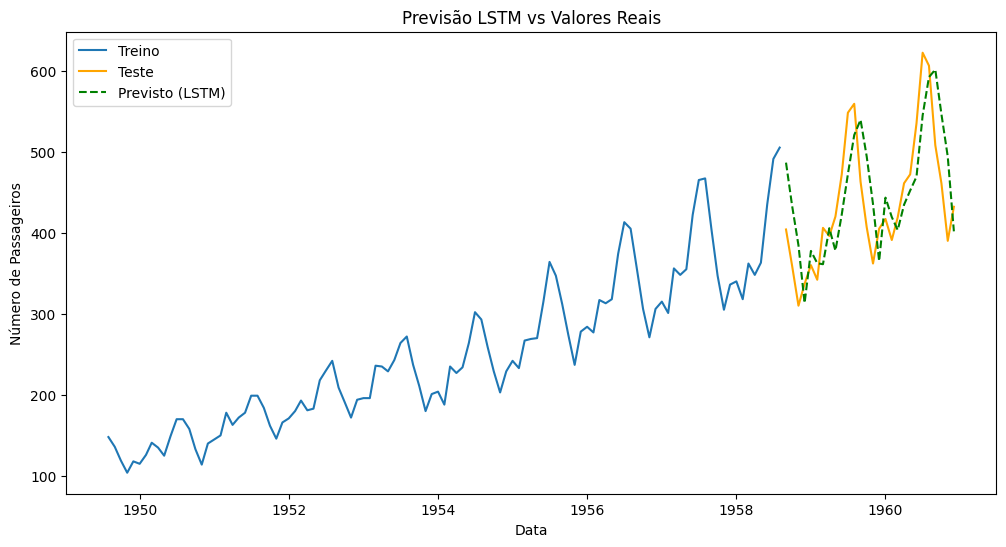

In [19]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_lstm, label='Previsto (LSTM)', color='green', linestyle='--')
plt.title('Previsão LSTM vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

> **Nota:**  
> Keras e TensorFlow são frameworks focados na definição e treino de redes neuronais, enquanto o scikit-learn foi desenvolvido principalmente para pipelines de modelos clássicos, validação cruzada e otimização de hiperparâmetros.  
> 
> Por esse motivo, não é possível utilizar diretamente o `GridSearchCV` com modelos LSTM definidos em Keras, como fizemos com os modelos anteriores (Random Forest e XGBoost).
> 
> Para contornar esta limitação, a comunidade disponibiliza integrações e *wrappers* que tornam os modelos Keras compatíveis com o scikit-learn.  
> 
> Assim, e com o objetivo de manter consistência metodológica no projeto, iremos utilizar o `KerasRegressor`, que nos permitirá aplicar o `GridSearchCV` ao modelo LSTM.


In [20]:
# Função para construir o modelo
def build_model(units=50, dropout_rate=0.2, activation='tanh', optimizer='adam', stacked=False, learning_rate=0.001):
    
    model = Sequential()

    if stacked:
        # Duas camadas LSTM
        model.add(LSTM(units=units,
                       activation=activation,
                       return_sequences=True,
                       input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(units=units, activation=activation))
    else:
        # Uma camada LSTM
        model.add(LSTM(units=units,
                       activation=activation,
                       input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    # Selecionar otimizador
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'nadam':
        opt = Nadam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Otimizador desconhecido: {optimizer}")

    model.compile(optimizer=opt, loss='mse')
    
    return model


In [21]:
# Empacotar o modelo para GridSearch
regressor = KerasRegressor(model=build_model, verbose=0)

# Espaço de busca dos hiperparâmetros
lstm_param_grid = {'model__units': [50, 64, 100],
                   'model__dropout_rate': [0.2, 0.3],
                   'model__activation': ['tanh', 'relu'],
                   'model__optimizer': ['adam', 'rmsprop'],
                   'model__stacked': [False, True],
                   'model__learning_rate': [0.001],  # fixo para limitar o tempo de execução
                   'batch_size': [16, 32],
                   'epochs': [50, 100]}

# Validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=3)

# GridSearch com scikeras
lstm_grid_search = GridSearchCV(estimator=regressor,
                                param_grid=lstm_param_grid,
                                scoring='neg_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                verbose=1)

# Treinar (demorado)
grid_result = lstm_grid_search.fit(X_train_lstm, y_train_scaled)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


In [22]:
# Resultados
print("Melhores parâmetros encontrados:")
print(grid_result.best_params_)

print("\nMelhor pontuação (Negative Mean Squared Error):")
print(grid_result.best_score_)

Melhores parâmetros encontrados:
{'batch_size': 16, 'epochs': 100, 'model__activation': 'relu', 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__optimizer': 'adam', 'model__stacked': True, 'model__units': 100}

Melhor pontuação (Negative Mean Squared Error):
-0.005243306029228099


In [23]:
# Previsões
lstm_best_model = grid_result.best_estimator_
y_pred_lstm = lstm_best_model.predict(X_test_lstm)

# Inversão da normalização
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Métricas de Avaliação
rmse_lstm2 = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm2 = mean_absolute_error(y_test, y_pred_lstm)
r2_score_lstm2 = r2_score(y_test, y_pred_lstm)

print("Resultados:")
print(f"RMSE: {rmse_lstm2:.2f}")
print(f"MAE: {mae_lstm2:.2f}")
print(f"R2_score: {r2_score_lstm2:.2f}")

Resultados:
RMSE: 57.97
MAE: 50.59
R2_score: 0.46


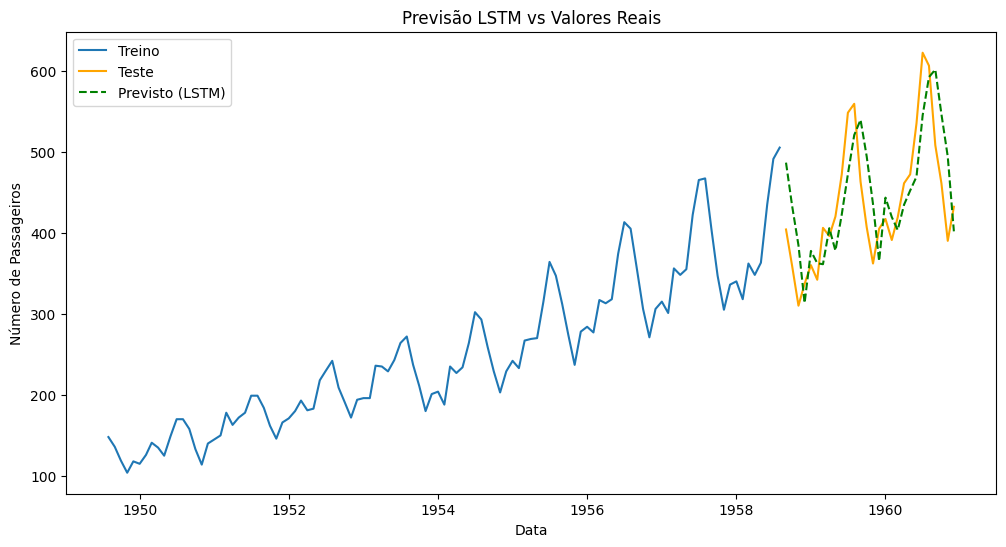

In [24]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_lstm, label='Previsto (LSTM)', color='green', linestyle='--')
plt.title('Previsão LSTM vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

## Comparação dos Modelos Antes e Depois da Otimização

| Modelo            | Métrica | Antes | Depois    | Melhoria?                  |
| ----------------- | ------- | ----- | --------- | -------------------------- |
| **SARIMA**        | RMSE    | –     | **35.10** | ✅ Melhor desempenho global |
|                   | MAE     | –     | **28.57** | ✅ Melhor desempenho global |
|                   | R²      | –     | **0.80**  | ✅ Melhor desempenho global |
| **Random Forest** | RMSE    | 76.24 | **63.47** | ✅ Sim (↓)                  |
|                   | MAE     | 58.35 | **41.19** | ✅ Sim (↓)                  |
|                   | R²      | 0.05  | **0.34**  | ✅ Sim (↑)                  |
| **XGBoost**       | RMSE    | 92.00 | **60.33** | ✅ Sim (↓)                  |
|                   | MAE     | 69.56 | **45.29** | ✅ Sim (↓)                  |
|                   | R²      | -0.39 | **0.41**  | ✅ Sim (↑)                  |
| **LSTM**          | RMSE    | 63.34 | **57.97** | ✅ Sim (↓)                  |
|                   | MAE     | 50.01 | **50.59** | ❌ Quase igual              |
|                   | R²      | 0.34  | **0.46**  | ✅ Sim (↑)                  |


## Conclusão da Otimização dos Modelos

Após a realização de engenharia de features e otimização de hiperparâmetros, foi possível observar uma melhoria clara em praticamente todos os modelos testados.

Resumo dos Resultados:
 - SARIMA destacou-se como o modelo mais robusto, atingindo RMSE de 35.10, MAE de 28.57 e um R² de 0.80, sendo o melhor entre todas as abordagens testadas;
- XGBoost e Random Forest apresentaram melhorias significativas em relação às versões iniciais, mostrando que o tuning e a seleção de features foram fundamentais para o ganho de desempenho;
- LSTM melhorou o R² e o RMSE, mas manteve o MAE praticamente inalterado. Este resultado sugere que o modelo consegue capturar bem as tendências, mas ainda encontra dificuldades em reduzir erros absolutos em determinadas previsões.

Considerações Finais:
- Para este conjunto de dados, o SARIMA mostrou-se a solução mais eficiente e precisa;
- Os modelos baseados em árvores (XGBoost e Random Forest) tiveram um bom desempenho após ajustes, o que reforça a importância da engenharia de features em séries temporais;
- A LSTM apresentou potencial, mas necessita de mais ajustes na arquitetura e nos hiperparâmetros para competir com o SARIMA neste caso específico.

Recomendação final:
 - SARIMA como modelo principal, mantendo em aberto a possibilidade de melhorias futuras em redes neurais recorrentes (LSTM) para explorar padrões mais complexos de longo prazo.

⚠️ Nota Importante sobre a Otimização

A otimização realizada neste notebook teve como objetivo demonstrar um processo prático de melhoria dos modelos, explorando engenharia de features e ajustes de hiperparâmetros.  
No entanto, é importante destacar que:
- Os valores utilizados nos grids de busca não garantem a otimização ótima;
- O espaço de busca pode ser expandido e refinado;
- Técnicas mais avançadas, como Bayesian Optimization, Optuna ou Hyperband, poderiam trazer ganhos adicionais;
- O tempo de execução também foi considerado, limitando o número de combinações testadas.

Os resultados apresentados devem ser entendidos como um exemplo representativo do processo de otimização e não como uma solução final definitiva.